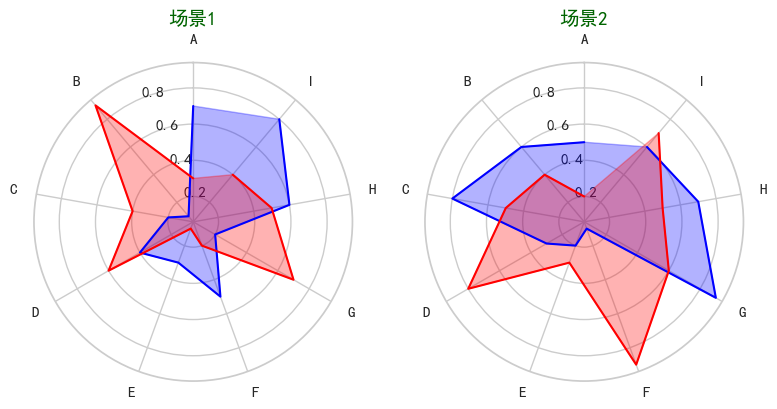

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, RegularPolygon
from matplotlib.projections import register_projection
from matplotlib.projections.polar import PolarAxes
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D
from matplotlib.path import Path
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置字体为黑体  
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

# 雷达图工厂函数，用于创建雷达图的轴对象
def create_radar_chart(num_vars, frame_type='circle'):
    """创建指定变量数量的雷达图投影"""
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)
    
    class RadarAxes(PolarAxes):
        """自定义的雷达图轴类"""
        name = 'radar'
        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            self.set_theta_zero_location('N')  # 设置第一个轴在顶部

        def _gen_axes_patch(self):
            """根据指定的框架类型创建轴的形状"""
            if frame_type == 'circle':
                return Circle((0.5, 0.5), 0.5)
            elif frame_type == 'polygon':
                return RegularPolygon((0.5, 0.5), num_vars, radius=0.5, edgecolor="k")
            else:
                raise ValueError(f"未知框架类型: {frame_type}")

        def set_varlabels(self, labels):
            """设置雷达图的标签"""
            self.set_thetagrids(np.degrees(angles), labels)

    register_projection(RadarAxes)
    return angles

# 生成示例数据
def get_sample_data():
    """返回用于绘制的示例数据"""
    labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I']  # 标签
    scenarios = [
        ('场景1', [[0.7, 0.1, 0.2, 0.4, 0.3, 0.5, 0.2, 0.6, 0.8], 
                   [0.3, 0.9, 0.4, 0.6, 0.1, 0.2, 0.7, 0.5, 0.4]]),
        ('场景2', [[0.5, 0.6, 0.8, 0.3, 0.2, 0.1, 0.9, 0.7, 0.6], 
                   [0.2, 0.4, 0.5, 0.8, 0.3, 0.9, 0.6, 0.5, 0.7]])
    ]
    return labels, scenarios

# 绘制雷达图
def plot_radar(labels, scenarios):
    num_vars = len(labels)
    angles = create_radar_chart(num_vars, frame_type='polygon')
    
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4),
                             subplot_kw=dict(projection='radar'))
    colors = ['blue', 'red']  # 颜色设置
    
    # 绘制每个场景的数据
    for ax, (title, case_data) in zip(axes, scenarios):
        ax.set_title(title, size=14, color='darkgreen', weight='bold')
        ax.set_rgrids([0.2, 0.4, 0.6, 0.8])  # 设置刻度
        
        for data, color in zip(case_data, colors):
            ax.plot(angles, data, color=color)
            ax.fill(angles, data, color=color, alpha=0.3)
        
        ax.set_varlabels(labels)  # 设置标签

    fig.tight_layout()
    plt.show()

# 主函数，运行绘制
if __name__ == '__main__':
    labels, scenarios = get_sample_data()
    plot_radar(labels, scenarios)


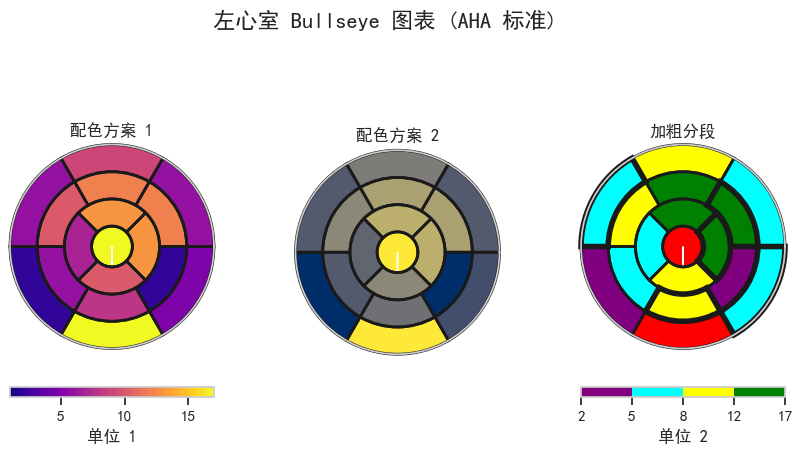

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

def plot_bullseye(ax, values, highlighted_segments=None, color_map="plasma", normalization=None):
    """
    绘制左心室的 bullseye 图表。

    参数:
    - ax : 坐标轴
    - values : list[float] 左心室每个分段的数值
    - highlighted_segments : list[int], 可选，指定需要加粗边界的分段
    - color_map : 配色方案
    - normalization : 数据归一化设置
    """
    values = np.ravel(values)  # 将数据展开成一维数组
    if highlighted_segments is None:
        highlighted_segments = []
    if normalization is None:
        normalization = mpl.colors.Normalize(vmin=values.min(), vmax=values.max())

    # 设置不同半径区域，每个区域包含多个分段
    radius_intervals = np.linspace(0.2, 1, 4)
    ax.set(ylim=[0, 1], xticks=[], yticks=[])  # 隐藏坐标轴刻度
    ax.grid(False)  # 移除网格线

    # 填充各个分段的颜色
    segments_info = [
        (0, 6, radius_intervals[2], radius_intervals[3]),  # 外圈
        (6, 12, radius_intervals[1], radius_intervals[2]), # 中圈
        (12, 16, radius_intervals[0], radius_intervals[1]), # 内圈
        (16, 17, 0, radius_intervals[0]) # 最内层
    ]
    
    for start, stop, r_inner, r_outer in segments_info:
        segment_count = stop - start
        angle_step = 2 * np.pi / segment_count
        ax.bar(np.arange(segment_count) * angle_step + np.pi / 2, r_outer - r_inner, angle_step, r_inner,
               color=color_map(normalization(values[start:stop])))

    # 绘制各个分段的边界线，加粗指定的分段
    for start, stop, r_inner, r_outer in segments_info[:-1]:  # 17号分段单独处理
        segment_count = stop - start
        angle_step = 2 * np.pi / segment_count
        ax.bar(np.arange(segment_count) * angle_step + np.pi / 2, r_outer - r_inner, angle_step, r_inner,
               color="none", edgecolor="k", clip_on=False, 
               linewidth=[4 if i + 1 in highlighted_segments else 2 for i in range(start, stop)])
    
    # 单独处理17号分段的边界线
    ax.plot(np.linspace(0, 2 * np.pi), np.full(50, radius_intervals[0]), "k",
            linewidth=(4 if 17 in highlighted_segments else 2))

# 生成模拟数据，17个分段数据
data_values = np.random.randint(1, 18, size=17)

# 创建图形和子图布局
fig, axes = plt.subplots(1, 3, figsize=(10, 5), subplot_kw={'projection': 'polar'})
fig.subplots_adjust(wspace=0.4)
fig.suptitle('左心室 Bullseye 图表 (AHA 标准)', fontsize=16)

# 设置不同的配色方案和数据归一化
cmap1 = mpl.cm.plasma
norm1 = mpl.colors.Normalize(vmin=1, vmax=17)
cmap2 = mpl.cm.cividis
norm2 = mpl.colors.Normalize(vmin=1, vmax=17)
cmap3 = mpl.colors.ListedColormap(['purple', 'cyan', 'yellow', 'green']).with_extremes(over='red', under='blue')
bounds = [2, 5, 8, 12, 17]
norm3 = mpl.colors.BoundaryNorm(bounds, cmap3.N)

# 第一个 bullseye 图
plot_bullseye(axes[0], data_values, color_map=cmap1, normalization=norm1)
axes[0].set_title('配色方案 1')

# 第二个 bullseye 图
plot_bullseye(axes[1], data_values, color_map=cmap2, normalization=norm2)
axes[1].set_title('配色方案 2')

# 第三个 bullseye 图，突出显示指定的分段
highlight_segments = [2, 5, 10, 12, 16]
plot_bullseye(axes[2], data_values, highlighted_segments=highlight_segments, color_map=cmap3, normalization=norm3)
axes[2].set_title('加粗分段')

# 添加颜色条，分别对应第一个和第三个图
fig.colorbar(mpl.cm.ScalarMappable(norm=norm1, cmap=cmap1), ax=axes[0], orientation='horizontal', pad=0.1, label='单位 1')
fig.colorbar(mpl.cm.ScalarMappable(norm=norm3, cmap=cmap3), ax=axes[2], orientation='horizontal', pad=0.1, label='单位 2')

plt.show()

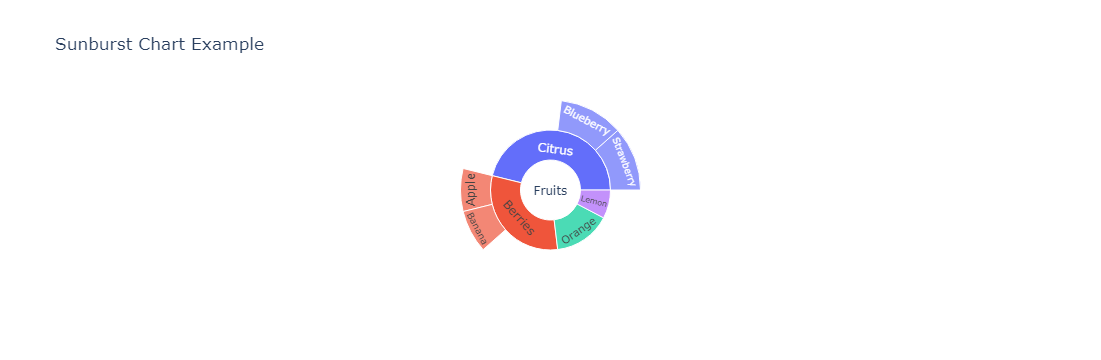

In [51]:
import plotly.express as px
import pandas as pd

# 创建示例数据
data = {
    'labels': ['Fruits', 'Berries', 'Citrus', 'Apple', 'Banana', 'Strawberry', 'Blueberry', 'Orange', 'Lemon'],
    'parents': ['', 'Fruits', 'Fruits', 'Berries', 'Berries', 'Citrus', 'Citrus', 'Fruits', 'Fruits'],
    'values': [0, 20, 30, 10, 10, 15, 15, 20, 10]
}
# 将数据转换为DataFrame
df = pd.DataFrame(data)

# 创建桑葚图
fig = px.sunburst(df, 
                  names='labels', 
                  parents='parents', 
                  values='values', 
                  title='Sunburst Chart Example')
# 显示图形
fig.show()